


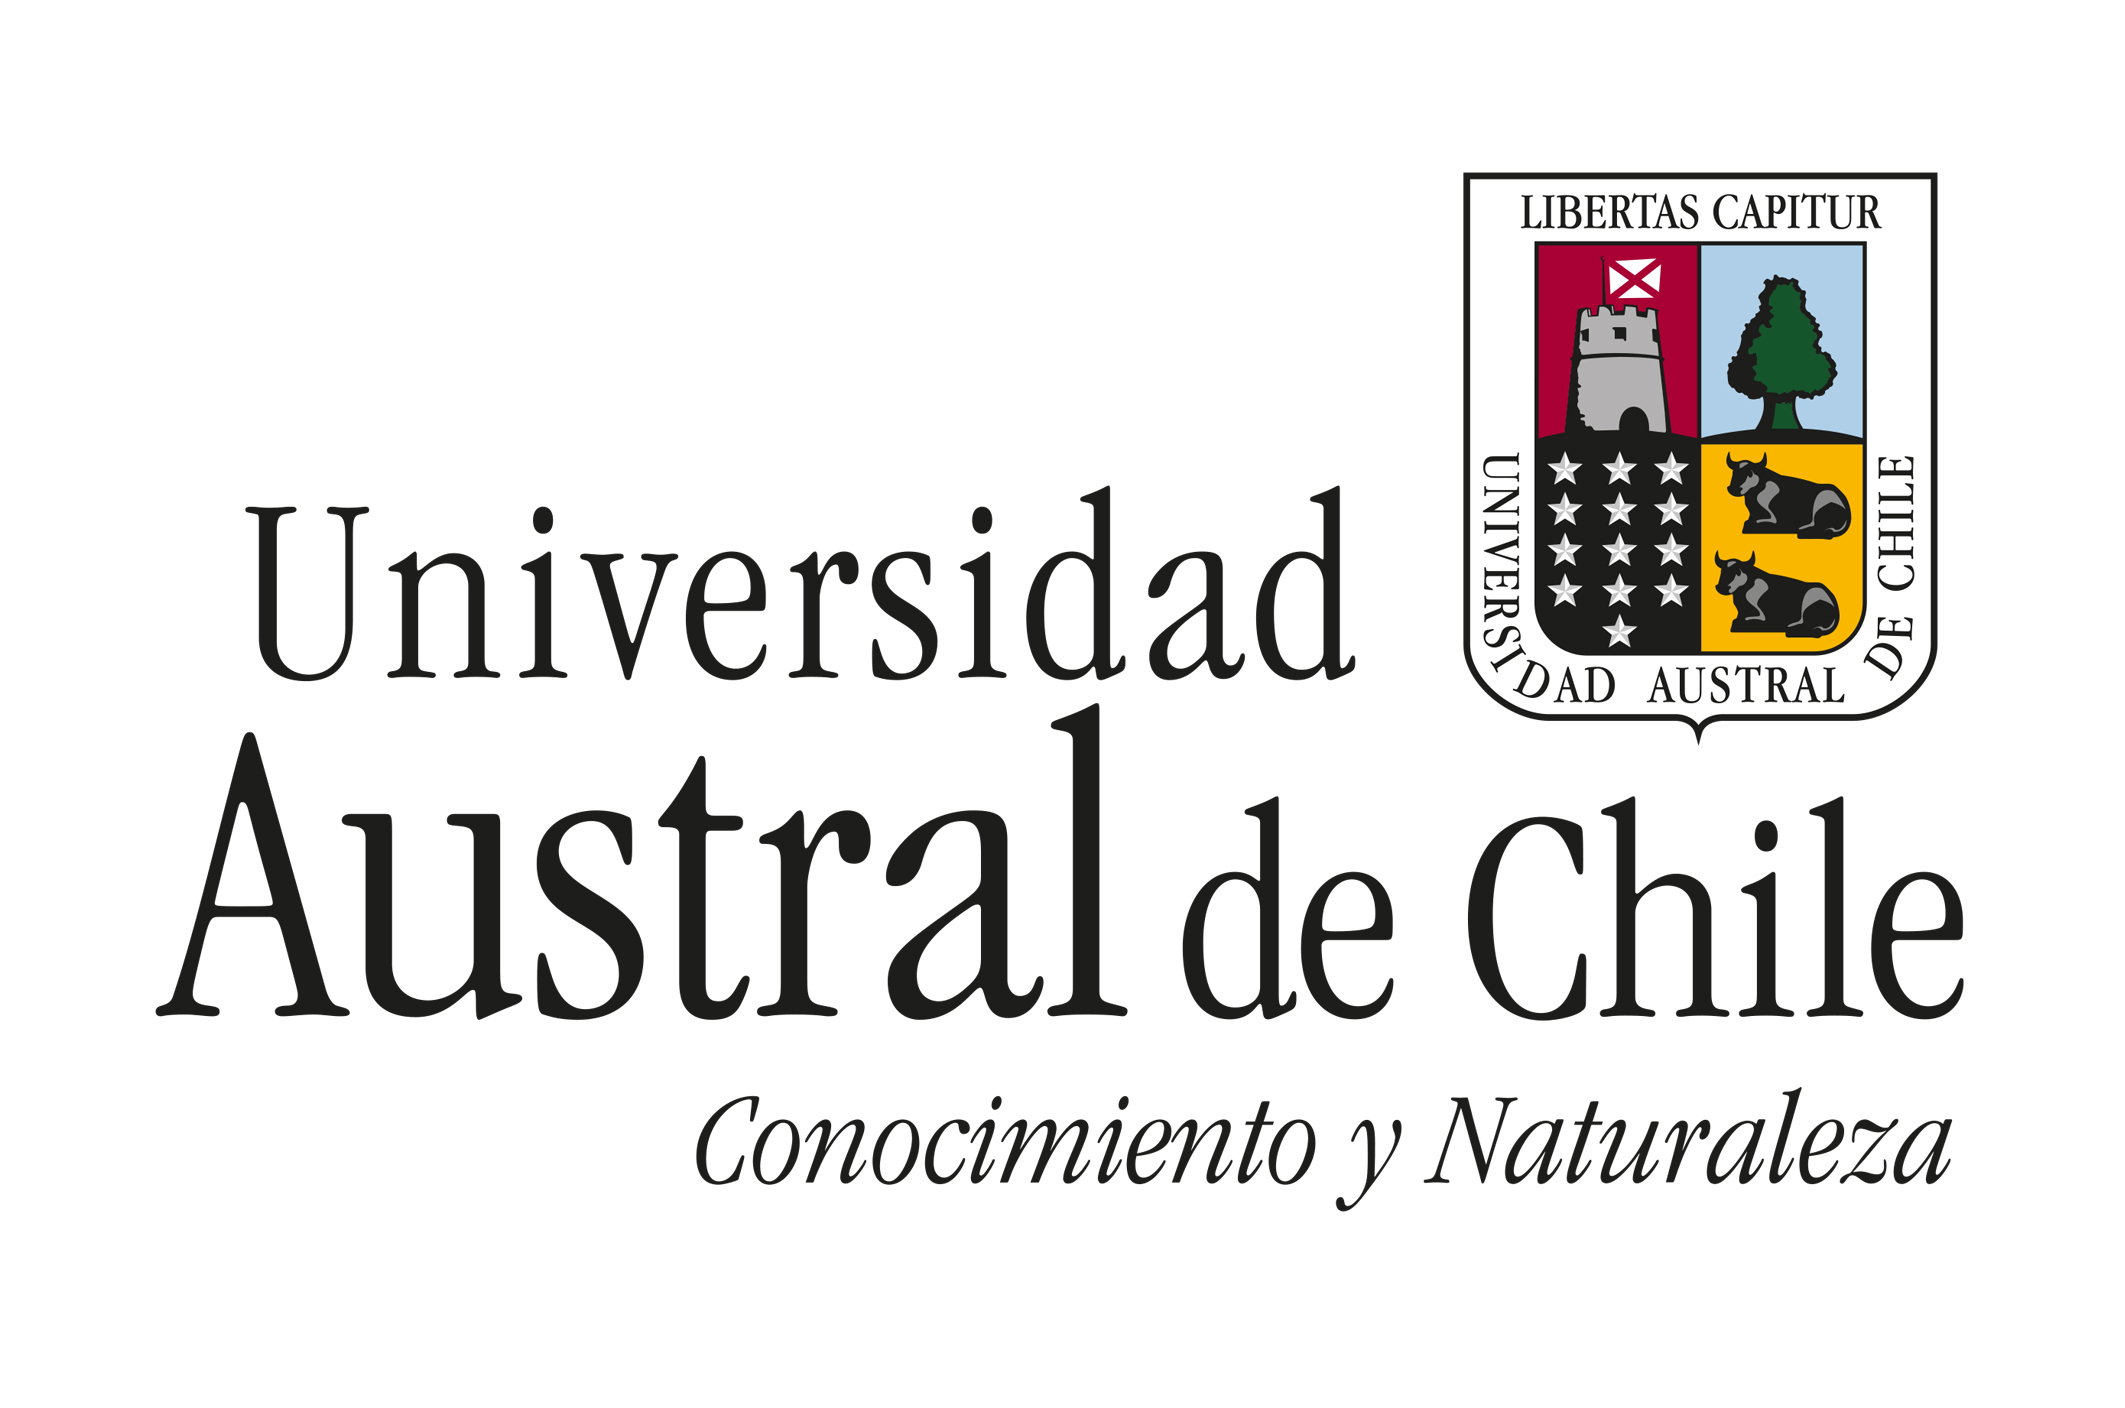

# Análisis de Vibraciones Estructurales Mediante Herramientas Computacionales
**Autor:** Martín de la Cuadra D. 
**Curso:** Análisis Vibraciones  
**Profesor:** Victor Poblete  
**Fecha:** 15/06/2026 

---

## Resumen

En este informe se estudia el comportamiento dinámico de sistemas vibratorios utilizando herramientas computacionales implementadas en Python. Se analizan señales temporales y espectrales de un sistema masa-resorte-amortiguador con el objetivo de identificar frecuencias naturales y estimar parámetros de amortiguamiento. Se implementan técnicas de análisis espectral mediante el método de Welch, evaluando su robustez frente al ruido en comparación con la transformada rápida de Fourier (FFT) directa y analizando el efecto de la duración de registro en la resolución en frecuencia. Además, se aplican algoritmos de detección de máximos (peaks) para estimar la razón de amortiguamiento estructural mediante el método del decremento logarítmico en señales con decaimiento libre. Finalmente, se discuten las limitaciones del método analítico, la influencia que tiene el ruido experimental en la precisión de las crestas temporales y la viabilidad de implementar estas técnicas en entornos de Monitoreo de Salud Estructural (SHM) utilizando sensores de aceleración.

## 1. Introducción

Las vibraciones mecánicas se encuentran presentes en múltiples sistemas de ingeniería, incluyendo estructuras civiles, sistemas acústicos y maquinaria pesada industrial. Monitorear e interpretar estas vibraciones es fundamental para garantizar la integridad estructural, evaluar la respuesta ante cargas dinámicas ambientales y prevenir fallas catastróficas.

El análisis vibratorio computacional permite identificar propiedades dinámicas críticas de una estructura a partir de su huella digital dinámica, tales como:
* Frecuencias naturales de oscilación.
* Niveles de amortiguamiento del material y del sistema.
* Zonas de resonancia y amplificación dinámica.
* Modos de vibración y formas de flexión estructural.

En este trabajo se desarrollan y aplican herramientas computacionales en Python para estudiar sistemas vibratorios de un grado de libertad (SDOF), evaluando señales simuladas para extraer sus propiedades fundamentales tanto en condiciones ideales como en escenarios con interferencia de ruido blanco.

### Objetivo General
Analizar señales vibracionales mediante herramientas computacionales para estimar parámetros dinámicos (frecuencia y amortiguamiento) de sistemas estructurales.

### Objetivos Específicos
* Modelar matemáticamente un sistema vibratorio de un grado de libertad.
* Analizar las respuestas de señales temporales y evaluar el impacto de las variables físicas en la tasa de decaimiento.
* Obtener espectros de potencia utilizando el método de Welch y evaluar la resolución espectral según el tiempo de adquisición.
* Identificar frecuencias dominantes y analizar las discrepancies numéricas derivadas de la discretización digital.
* Estimar la razón y el coeficiente de amortiguamiento viscoso mediante el decremento logarítmico, caracterizando su sensibilidad frente al ruido de medición.

## 2. Sistema masa resorte

### 2.1 Sistema Masa-Resorte-Amortiguador

Un modelo fundamental de vibración estructural puede representarse como un sistema de un grado de libertad (SDOF). Este modelo surge del equilibrio dinámico descrito por la segunda ley de Newton:

$$
\sum F = m\ddot{x}(t)
$$

Considerando una fuerza restauradora elástica proporcional al desplazamiento:

$$
F_k=-kx
$$

y una fuerza de amortiguamiento viscoso proporcional a la velocidad:

$$
F_c=-c\dot{x}
$$

el equilibrio dinámico conduce a la ecuación diferencial de movimiento para vibración libre amortiguada:

$$
m\ddot{x}(t)+c\dot{x}(t)+kx(t)=0
$$

donde:

* $m$ representa la masa inercial del sistema.
* $c$ corresponde al coeficiente de amortiguamiento viscoso.
* $k$ representa la rigidez elástica del sistema.
* $x(t)$ corresponde al desplazamiento en función del tiempo.

Esta ecuación constituye la base del análisis dinámico, ya que permite estudiar cómo evolucionan temporalmente las oscilaciones y cómo influyen los parámetros físicos del sistema sobre su respuesta.

---

### 2.2 Solución Temporal del Sistema

Para un sistema subamortiguado ($0<\zeta<1$), sometido a una condición inicial de desplazamiento $x_0$ y velocidad inicial nula ($\dot{x}_0=0$), la solución analítica de la ecuación diferencial es:

$$
x(t)=x_0 e^{-\zeta\omega_n t}
\left[
\cos(\omega_d t)
+
\frac{\zeta}{\sqrt{1-\zeta^2}}
\sin(\omega_d t)
\right]
$$

donde:

$$
\omega_n=\sqrt{\frac{k}{m}}
$$

es la frecuencia natural no amortiguada,

$$
\zeta=\frac{c}{2\sqrt{km}}
$$

es la razón de amortiguamiento adimensional y

$$
\omega_d=\omega_n\sqrt{1-\zeta^2}
$$

corresponde a la frecuencia natural amortiguada.

De manera equivalente, la solución puede expresarse en forma compacta como:

$$
x(t)=A e^{-\zeta\omega_n t}\cos(\omega_d t-\phi)
$$

donde las constantes $A$ y $\phi$ dependen de las condiciones iniciales impuestas al sistema.


### 2.3 Clasificación según la Razón de Amortiguamiento

Dependiendo del valor de $\zeta$, pueden distinguirse tres comportamientos dinámicos principales:

* **Subamortiguado ($0 < \zeta < 1$):** el sistema oscila mientras su amplitud disminuye progresivamente.
* **Críticamente amortiguado ($\zeta = 1$):** el sistema retorna al equilibrio en el menor tiempo posible sin oscilar.
* **Sobreamortiguado ($\zeta > 1$):** el retorno al equilibrio ocurre sin oscilaciones, pero más lentamente que en el caso crítico.

En estructuras civiles, maquinaria y sistemas acústicos es común encontrar respuestas subamortiguadas, razón por la cual este régimen constituye el principal foco de análisis en el presente trabajo.

---

### 2.5 Relación entre Parámetros Físicos y Respuesta Dinámica

La frecuencia natural del sistema depende de la relación entre rigidez y masa:

$$
\omega_n=\sqrt{\frac{k}{m}}
$$

Por lo tanto:

* Un aumento de la rigidez $k$ incrementa la frecuencia natural.
* Un aumento de la masa $m$ reduce la frecuencia natural.
* Un aumento del amortiguamiento $\zeta$ acelera el decaimiento de la amplitud.

Estas relaciones serán verificadas posteriormente mediante simulaciones computacionales interactivas, permitiendo visualizar cómo las modificaciones de cada parámetro alteran la respuesta temporal del sistema.


In [35]:
# 3.1 Librerías Utilizadas
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
from scipy.signal import find_peaks
from scipy import signal
from ipywidgets import interact, FloatSlider
from IPython.display import clear_output

In [36]:
# 3.2 Parámetros del Sistema Base
m = 2              # Masa (kg)
k = 500            # Rigidez (N/m)
zeta_real = 0.03    # Razón de amortiguamiento teórica (3%)

In [37]:
# 4.1 Cálculo de Frecuencia Natural Teórica
wn = np.sqrt(k/m)
fn = wn/(2*np.pi)
print(f"Frecuencia natural teórica: {fn:.4f} Hz")

Frecuencia natural teórica: 2.5165 Hz


In [38]:
import matplotlib as mpl

print(mpl.rcParams['text.usetex'])

False


In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from ipywidgets import interact, FloatSlider

def generar_grafico_interactivo(mass, stiffness, damping_ratio):

    # Tiempo y frecuencia de muestreo
    fs = 1000
    t = np.linspace(0, 10, fs * 10)

    # Frecuencia natural
    omega_n = np.sqrt(stiffness / mass)
    fn = omega_n / (2 * np.pi)

    # Respuesta libre amortiguada
    if damping_ratio < 1:

        omega_d = omega_n * np.sqrt(max(0, 1 - damping_ratio**2))

        u_limpia = (
            np.exp(-damping_ratio * omega_n * t)
            * np.cos(omega_d * t)
        )

    elif np.isclose(damping_ratio, 1):

        # Amortiguamiento crítico
        u_limpia = np.exp(-omega_n * t) * (1 + omega_n * t)

    else:

        # Sobreamortiguado
        r1 = -omega_n * (
            damping_ratio - np.sqrt(damping_ratio**2 - 1)
        )

        r2 = -omega_n * (
            damping_ratio + np.sqrt(damping_ratio**2 - 1)
        )

        u_limpia = (
            0.5 * np.exp(r1 * t)
            + 0.5 * np.exp(r2 * t)
        )

    # Ruido
    np.random.seed(42)
    ruido = np.random.normal(0, 0.05, len(t))
    u_medida = u_limpia + ruido

    # PSD usando Welch
    f, psd = signal.welch(
        u_medida,
        fs=fs,
        nperseg=1024
    )

    # Figura
    fig, (ax1, ax2) = plt.subplots(
        1,
        2,
        figsize=(14, 5)
    )

    # Respuesta temporal
    ax1.plot(
        t,
        u_medida,
        color='gray',
        alpha=0.5,
        label='Señal medida'
    )

    ax1.plot(
        t,
        u_limpia,
        color='blue',
        linewidth=2,
        label='Respuesta teórica'
    )

    ax1.set_title(
        f'Respuesta Temporal\nζ = {damping_ratio:.2f}'
    )

    ax1.set_xlabel('Tiempo [s]')
    ax1.set_ylabel('Amplitud')
    ax1.set_ylim(-1.5, 1.5)
    ax1.grid(True)
    ax1.legend()

    # PSD
    ax2.semilogy(
        f,
        psd,
        color='crimson',
        linewidth=2
    )

    ax2.axvline(
        fn,
        color='black',
        linestyle='--',
        linewidth=2,
        label=f'fn = {fn:.2f} Hz'
    )

    ax2.set_title(
        f'PSD (Método de Welch)\nfn = {fn:.2f} Hz'
    )

    ax2.set_xlabel('Frecuencia [Hz]')
    ax2.set_ylabel('PSD')

    # Ajuste automático del eje x
    xmax = max(15, fn * 2)
    ax2.set_xlim(0, xmax)

    ax2.grid(True)
    ax2.legend()

    plt.tight_layout()
    plt.show()

    plt.close(fig)

# Interfaz
interact(
    generar_grafico_interactivo,

    mass=FloatSlider(
        value=2.0,
        min=0.5,
        max=10.0,
        step=0.5,
        description='Masa'
    ),

    stiffness=FloatSlider(
        value=500,
        min=50,
        max=4000,
        step=50,
        description='Rigidez'
    ),

    damping_ratio=FloatSlider(
        value=0.03,
        min=0.00,
        max=1.00,
        step=0.01,
        description='Zeta'
    )
);

interactive(children=(FloatSlider(value=2.0, description='Masa', max=10.0, min=0.5, step=0.5), FloatSlider(val…

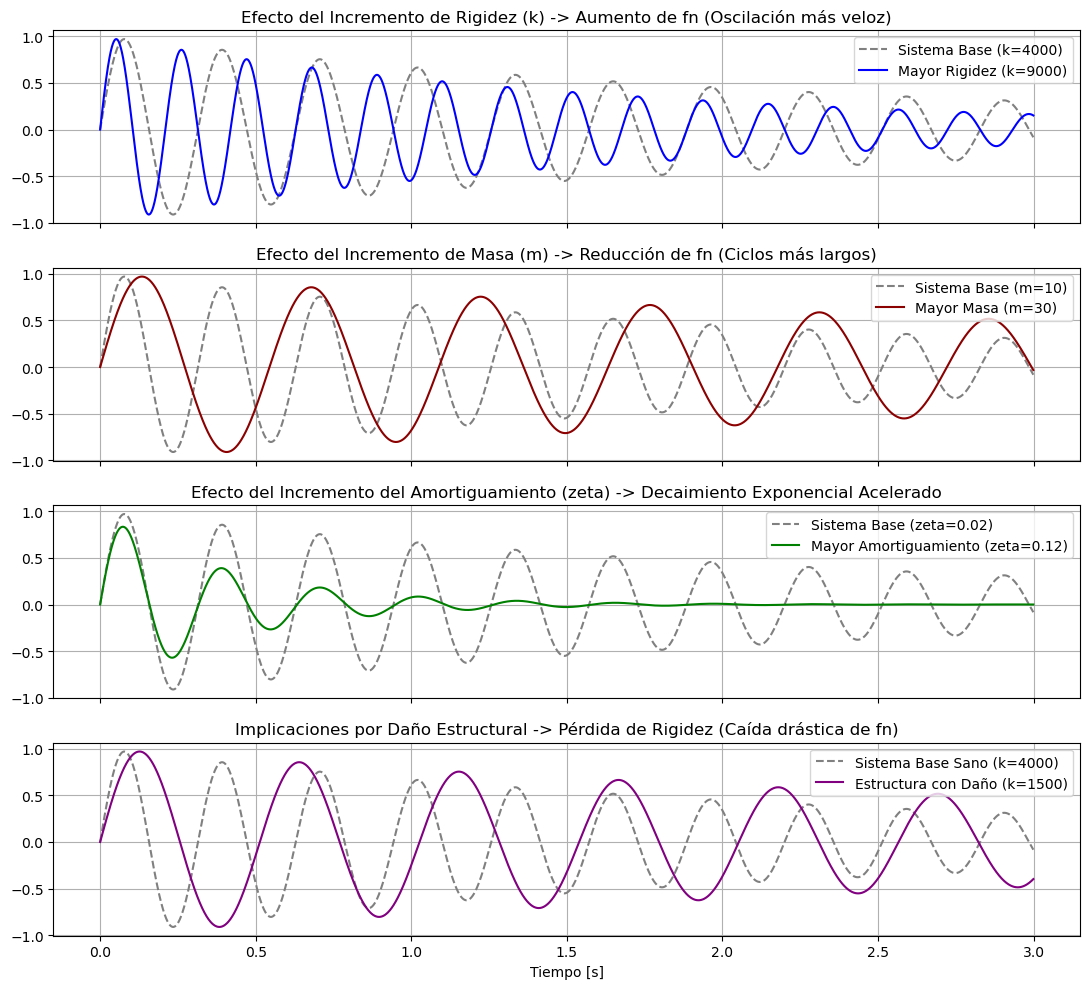

In [6]:
# 4.3 LABORATORIO DE SENSIBILIDAD: Código demostrativo de cambios físicos
fs = 1000
t_lab = np.arange(0, 3, 1/fs) # Ventana temporal de 3 segundos para observar transitorios

# Funciones auxiliares para modelar la señal temporal subamortiguada según parámetros
def simular_respuesta(m_val, k_val, zeta_val, tiempo):
    wn_val = np.sqrt(k_val / m_val)
    wd_val = wn_val * np.sqrt(1 - zeta_val**2)
    return np.exp(-zeta_val * wn_val * tiempo) * np.sin(wd_val * tiempo)

# Simulaciones experimentales
x_base       = simular_respuesta(m_val=10, k_val=4000, zeta_val=0.02, tiempo=t_lab)
x_mas_k      = simular_respuesta(m_val=10, k_val=9000, zeta_val=0.02, tiempo=t_lab)  # Rigidez k aumenta de 4000 a 9000
x_mas_m      = simular_respuesta(m_val=30, k_val=4000, zeta_val=0.02, tiempo=t_lab)  # Masa m aumenta de 10 a 30
x_mas_zeta   = simular_respuesta(m_val=10, k_val=4000, zeta_val=0.12, tiempo=t_lab)  # Amortiguamiento zeta aumenta de 0.02 a 0.12
x_dano       = simular_respuesta(m_val=10, k_val=1500, zeta_val=0.02, tiempo=t_lab)  # Pérdida de rigidez por daño (k cae a 1500)

# Configuración de gráficos comparativos
fig, axs = plt.subplots(4, 1, figsize=(11, 10), sharex=True)

# Grafico 1: Efecto del aumento de Rigidez (k)
axs[0].plot(t_lab, x_base, 'gray', linestyle='--', label='Sistema Base (k=4000)')
axs[0].plot(t_lab, x_mas_k, 'blue', label='Mayor Rigidez (k=9000)')
axs[0].set_title("Efecto del Incremento de Rigidez (k) -> Aumento de fn (Oscilación más veloz)")
axs[0].legend(loc='upper right')
axs[0].grid(True)

# Grafico 2: Efecto del aumento de Masa (m)
axs[1].plot(t_lab, x_base, 'gray', linestyle='--', label='Sistema Base (m=10)')
axs[1].plot(t_lab, x_mas_m, 'darkred', label='Mayor Masa (m=30)')
axs[1].set_title("Efecto del Incremento de Masa (m) -> Reducción de fn (Ciclos más largos)")
axs[1].legend(loc='upper right')
axs[1].grid(True)

# Grafico 3: Efecto del aumento de Amortiguamiento (zeta)
axs[2].plot(t_lab, x_base, 'gray', linestyle='--', label='Sistema Base (zeta=0.02)')
axs[2].plot(t_lab, x_mas_zeta, 'green', label='Mayor Amortiguamiento (zeta=0.12)')
axs[2].set_title("Efecto del Incremento del Amortiguamiento (zeta) -> Decaimiento Exponencial Acelerado")
axs[2].legend(loc='upper right')
axs[2].grid(True)

# Grafico 4: Simulación de Daño Estructural
axs[3].plot(t_lab, x_base, 'gray', linestyle='--', label='Sistema Base Sano (k=4000)')
axs[3].plot(t_lab, x_dano, 'purple', label='Estructura con Daño (k=1500)')
axs[3].set_title("Implicaciones por Daño Estructural -> Pérdida de Rigidez (Caída drástica de fn)")
axs[3].set_xlabel("Tiempo [s]")
axs[3].legend(loc='upper right')
axs[3].grid(True)

plt.tight_layout()
plt.show()

### 2.6 Discusión de la Respuesta Temporal y Sensibilidad Física

El comportamiento observado en las gráficas superiores responde directamente a las ecuaciones constitutivas del sistema SDOF. Al analizar dinámicamente el modelo, se obtienen las siguientes conclusiones de sensibilidad:

* **Efecto del Incremento de Rigidez ($k$):** Dado que la frecuencia natural es proporcional a $\sqrt{k}$, un incremento en la rigidez estructural provocará un aumento directo de la frecuencia natural ($f_n$). La estructura se vuelve dinámicamente más "rígida" y oscilará más rápido en el tiempo.
* **Efecto del Incremento de Masa ($m$):** Al encontrarse la masa en el denominador de la relación ($\sqrt{k/m}$), un aumento de la masa inercial reduce la frecuencia natural ($f_n$). Las estructuras más pesadas exhiben ciclos temporales más largos (períodos mayores) si mantienen la misma rigidez.
* **Efecto del Incremento del Amortiguamiento ($c$ o $\zeta$):** En la señal temporal, un aumento del parámetro de amortiguamiento causa que la amplitud de la oscilación decaerá de forma notablemente más acelerada en el tiempo. La envolvente exponencial $e^{-\zeta\omega_n t}$ restringe la amplitud máxima ciclo tras ciclo.
* **Implicaciones por Daño Estructural:** La aparición de daño (como grietas, fatiga o degradación de soportes) se manifiesta físicamente como una **pérdida de rigidez elástica ($k$)**. Al disminuir $k$, la frecuencia natural del sistema se desplaza hacia valores más bajos. Por ende, el monitoreo continuo de la caída de las frecuencias naturales constituye uno de los pilares del diagnóstico no destructivo para la detección de daño estructural.

## 3. Análisis Espectral mediante PSD y Método de Welch


Mientras que la respuesta temporal permite observar cómo evoluciona el desplazamiento del sistema a lo largo del tiempo, el análisis espectral permite identificar las frecuencias que dominan el comportamiento vibratorio.

Para una vibración libre amortiguada, la respuesta del sistema puede describirse como:

$$
x(t)=A e^{-\zeta\omega_n t}\cos(\omega_d t-\phi)
$$

donde la amplitud disminuye progresivamente debido al amortiguamiento, mientras que la frecuencia de vibración permanece aproximadamente constante.

Con el objetivo de identificar estas frecuencias dominantes, la señal se transforma desde el dominio del tiempo al dominio de la frecuencia mediante la Transformada de Fourier. 
$$
X[k]=\sum_{n=0}^{N-1}
x[n]
e^{-j2\pi kn/N}
$$

donde $x[n]$ corresponde a la señal temporal muestreada y $X[k]$ representa sus componentes espectrales.



A partir de esta transformación se calcula la **Densidad Espectral de Potencia (PSD)**, la cual indica cómo se distribuye la energía vibratoria en función de la frecuencia.

Los máximos de la PSD suelen coincidir con las frecuencias naturales del sistema, permitiendo identificar los modos de vibración predominantes.

En señales experimentales, la estimación espectral puede verse afectada por ruido y fluctuaciones aleatorias. Para obtener resultados más estables se emplea el **método de Welch**, que consiste en dividir la señal en segmentos, calcular el espectro de cada uno y posteriormente promediarlos.

$$
PSD_{Welch}=
\frac{1}{M}
\sum_{i=1}^{M}
PSD_i(f)
$$

$$
PSD(f)
=\frac{|X(f)|^2}{T}
$$

donde:

* $|X(f)|^2$ representa potencia espectral.
* $T$ corresponde al tiempo total del registro.

La PSD permite responder:

Este procedimiento reduce la varianza espectral y produce estimaciones más robustas que una FFT calculada directamente sobre toda la señal.

Finalmente, la capacidad para distinguir frecuencias cercanas depende de la resolución frecuencial:

$$
\Delta f = \frac{1}{T}
$$

donde $T$ corresponde a la duración total del registro. Por lo tanto, registros más largos permiten una mejor separación entre frecuencias próximas.

En síntesis, el análisis temporal responde a la pregunta:

> ¿Cómo cambia el movimiento con el tiempo?

mientras que el análisis espectral responde:

> ¿Qué frecuencias explican ese movimiento?

Por esta razón, la PSD constituye una herramienta fundamental para la identificación de frecuencias naturales y el análisis dinámico de estructuras.


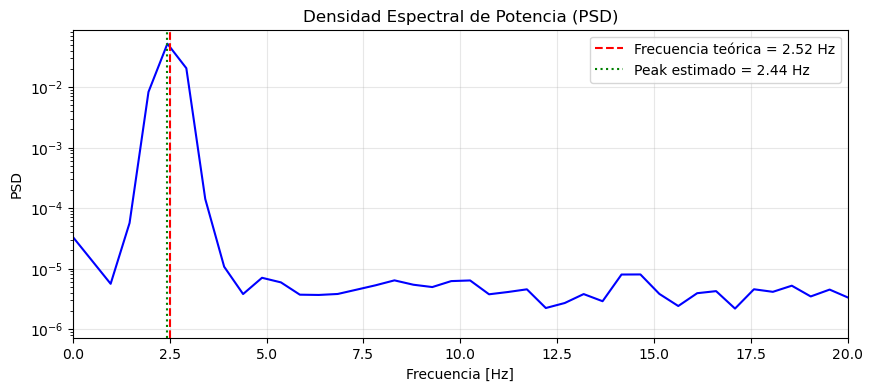

Frecuencia teórica: 2.5165 Hz
Frecuencia estimada: 2.4414 Hz
Diferencia: 0.0751 Hz


In [7]:
# 5.1 Estimación de PSD Mediante Welch y Frecuencia Dominante

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# Parámetros del sistema
fs = 1000
t = np.arange(0, 10, 1/fs)

m = 2.0
k = 500
zeta = 0.03

# Frecuencia natural teórica
omega_n = np.sqrt(k/m)
fn = omega_n/(2*np.pi)

# Respuesta libre amortiguada
omega_d = omega_n*np.sqrt(1-zeta**2)

x = (
    np.exp(-zeta*omega_n*t)
    * np.cos(omega_d*t)
)

# Agregar ruido para simular medición real
np.random.seed(42)
x += 0.05*np.random.randn(len(t))

# PSD mediante Welch
f_base, Pxx_base = welch(
    x,
    fs=fs,
    nperseg=2048
)

# Frecuencia dominante estimada
indice_peak = np.argmax(Pxx_base)
frecuencia_peak = f_base[indice_peak]

# Gráfico
plt.figure(figsize=(10,4))

plt.semilogy(
    f_base,
    Pxx_base,
    color='blue'
)

plt.axvline(
    fn,
    color='red',
    linestyle='--',
    label=f'Frecuencia teórica = {fn:.2f} Hz'
)

plt.axvline(
    frecuencia_peak,
    color='green',
    linestyle=':',
    label=f'Peak estimado = {frecuencia_peak:.2f} Hz'
)

plt.title('Densidad Espectral de Potencia (PSD)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD')
plt.xlim(0,20)
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

print(f"Frecuencia teórica: {fn:.4f} Hz")
print(f"Frecuencia estimada: {frecuencia_peak:.4f} Hz")
print(f"Diferencia: {abs(fn-frecuencia_peak):.4f} Hz")

### 3.1 Interpretación y Discrepancia Espectral

En este ejemplo, el sistema tiene una frecuencia natural teórica cercana a **2.52 Hz**. Al calcular la PSD de la señal medida, el peak dominante aparece muy cerca de ese valor, demostrando que **las propiedades físicas de una estructura dejan una huella clara en su respuesta dinámica**.

**¿Por qué la frecuencia dominante estimada desde la PSD no coincide exactamente con la frecuencia teórica?**
Esta discrepancia numérica no es un error físico, sino un fenómeno de procesamiento digital de señales conocido como **discretización y resolución en frecuencia**.
* Al transformar la señal al dominio de la frecuencia mediante algoritmos digitales (como la FFT usada dentro del método de Welch), el espectro continuo se divide en intervalos fijos o "bins" discretos espaciados por $\Delta f$.
* Si la verdadera frecuencia natural del sistema cae en el espacio intermedio entre dos de estos "bins", el algoritmo simplemente seleccionará el bin más cercano que posea la mayor energía (efecto *picket-fence*).
* Por lo tanto, el valor estimado está limitado por la resolución en frecuencia de la medición. Para hacer que coincidan con mayor exactitud, sería necesario aumentar la resolución espectral (por ejemplo, aumentando la duración total de la señal analizada).

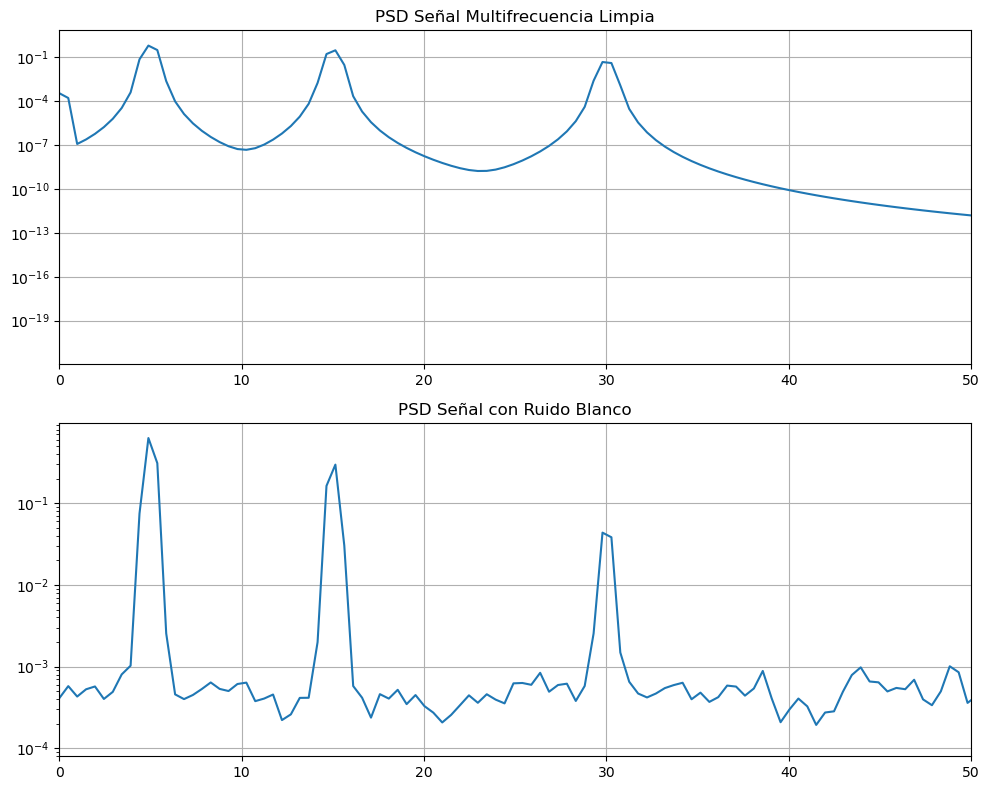

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# Parámetros
fs = 1000
duracion = 10

t = np.arange(0, duracion, 1/fs)

# Señal multifrecuencia
x_multi = (
    np.sin(2*np.pi*5*t)
    + 0.7*np.sin(2*np.pi*15*t)
    + 0.3*np.sin(2*np.pi*30*t)
)

# Ruido blanco
np.random.seed(42)
ruido = 0.5*np.random.randn(len(t))

# Señal contaminada
x_ruido = x_multi + ruido

# PSD mediante Welch
f_multi, Pxx_multi = welch(
    x_multi,
    fs=fs,
    nperseg=2048
)

f_ruido, Pxx_ruido = welch(
    x_ruido,
    fs=fs,
    nperseg=2048
)

# Comparación
fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(10,8)
)

ax1.semilogy(f_multi, Pxx_multi)
ax1.set_title("PSD Señal Multifrecuencia Limpia")
ax1.set_xlim(0,50)
ax1.grid(True)

ax2.semilogy(f_ruido, Pxx_ruido)
ax2.set_title("PSD Señal con Ruido Blanco")
ax2.set_xlim(0,50)
ax2.grid(True)

plt.tight_layout()
plt.show()

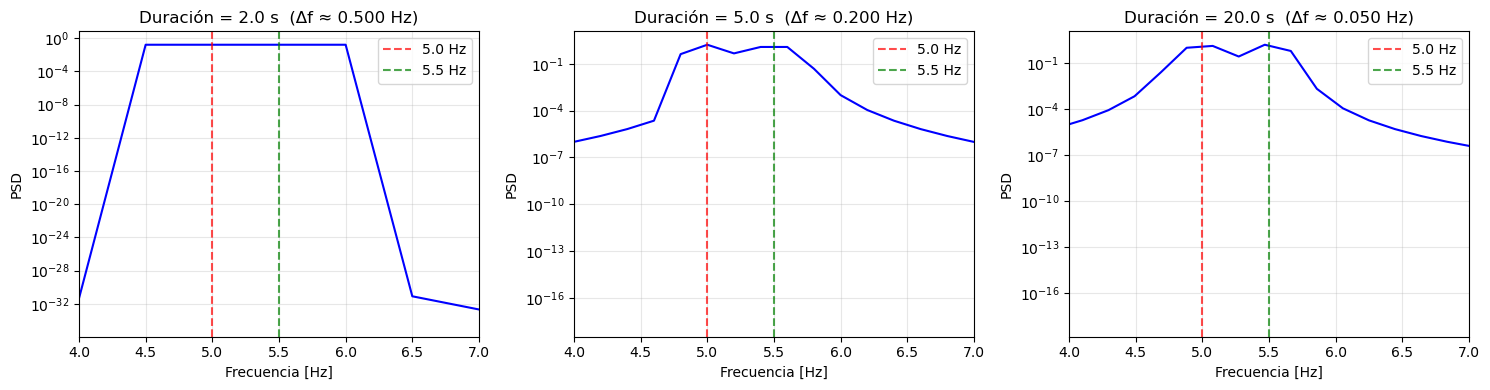

In [9]:
# 5.3.2 Efecto de la duración de la señal en la resolución en frecuencia
# Generamos una señal con dos frecuencias muy cercanas (5.0 y 5.5 Hz)
# y variamos la duración para ver cómo mejora la separación espectral.

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# Parámetros comunes
fs = 200.0  # frecuencia de muestreo [Hz]
f_a = 5.0   # primera frecuencia [Hz]
f_b = 5.5   # segunda frecuencia [Hz]
amplitud_a = 1.0
amplitud_b = 1.0

# Duraciones a probar (segundos)
durations = [2.0, 5.0, 20.0]

# Crear figura con subgráficos en una fila
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, dur in enumerate(durations):
    # Generar la señal
    t_local = np.arange(0, dur, 1/fs)
    x_local = (amplitud_a * np.sin(2*np.pi*f_a*t_local) +
               amplitud_b * np.sin(2*np.pi*f_b*t_local))
    
    # Calcular PSD con Welch (nperseg = mínimo entre 1024 y la longitud de la señal)
    nperseg = min(1024, len(x_local))
    freqs, psd = welch(x_local, fs=fs, nperseg=nperseg, noverlap=nperseg//2)
    
    # Graficar
    ax = axes[i]
    ax.semilogy(freqs, psd, color='blue', linewidth=1.5)
    # Marcar las frecuencias reales
    ax.axvline(f_a, color='red', linestyle='--', alpha=0.7, label=f'{f_a} Hz')
    ax.axvline(f_b, color='green', linestyle='--', alpha=0.7, label=f'{f_b} Hz')
    
    ax.set_title(f'Duración = {dur:.1f} s  (Δf ≈ {1/dur:.3f} Hz)')
    ax.set_xlabel('Frecuencia [Hz]')
    ax.set_ylabel('PSD')
    ax.set_xlim(4, 7)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

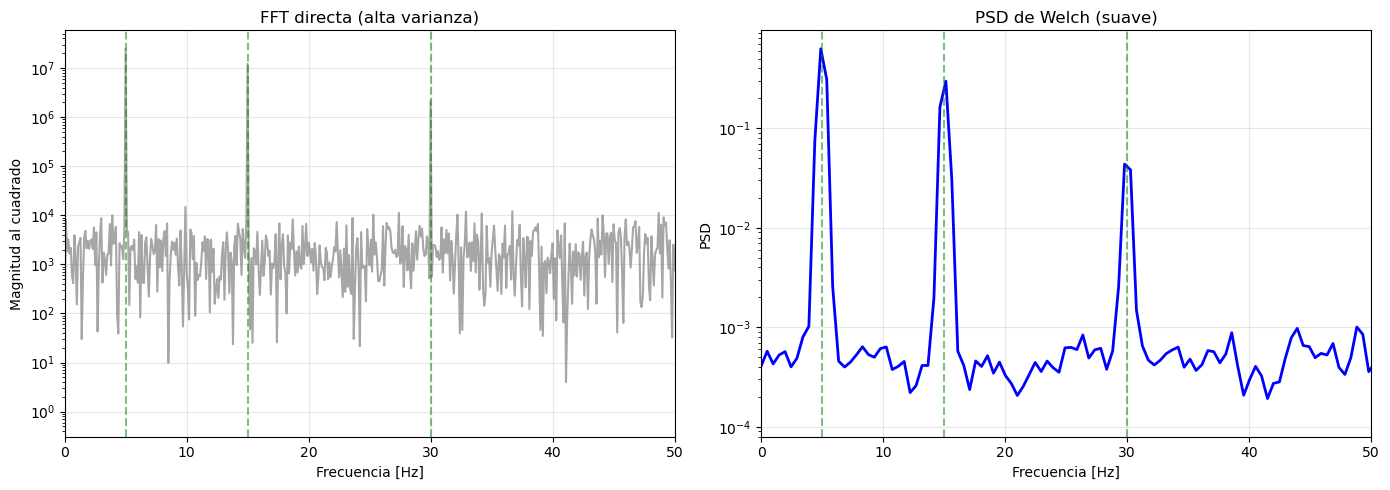

In [10]:
# 5.3.1 Comparación FFT directa vs. PSD de Welch

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# Crear señal si no existe
fs = 1000
t = np.arange(0, 10, 1/fs)

x_multi = (
    np.sin(2*np.pi*5*t)
    + 0.7*np.sin(2*np.pi*15*t)
    + 0.3*np.sin(2*np.pi*30*t)
)

np.random.seed(42)
ruido = 0.5*np.random.randn(len(t))

x_ruido = x_multi + ruido

# FFT directa
fft_values = np.fft.rfft(x_ruido)
fft_freqs = np.fft.rfftfreq(len(x_ruido), 1/fs)
fft_magnitude = np.abs(fft_values)**2

# PSD con Welch
f_ruido, Pxx_ruido = welch(
    x_ruido,
    fs=fs,
    nperseg=2048,
    noverlap=1024
)

# Figura comparativa
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# FFT directa
ax1.semilogy(
    fft_freqs,
    fft_magnitude,
    color='gray',
    alpha=0.7
)

ax1.set_title('FFT directa (alta varianza)', fontsize=12)
ax1.set_xlabel('Frecuencia [Hz]')
ax1.set_ylabel('Magnitud al cuadrado')
ax1.set_xlim(0, 50)
ax1.grid(True, alpha=0.3)

for f_real in [5, 15, 30]:
    ax1.axvline(
        f_real,
        color='green',
        linestyle='--',
        alpha=0.5
    )

# PSD de Welch
ax2.semilogy(
    f_ruido,
    Pxx_ruido,
    color='blue',
    linewidth=2
)

ax2.set_title('PSD de Welch (suave)', fontsize=12)
ax2.set_xlabel('Frecuencia [Hz]')
ax2.set_ylabel('PSD')
ax2.set_xlim(0, 50)
ax2.grid(True, alpha=0.3)

for f_real in [5, 15, 30]:
    ax2.axvline(
        f_real,
        color='green',
        linestyle='--',
        alpha=0.5
    )

plt.tight_layout()
plt.show()

### 3.2 Discusión del Comportamiento Espectral

* **Señal Limpia vs. Señal con Ruido:** La señal limpia muestra picos agudos que descienden directamente hasta el límite numérico del software. Al incorporar el ruido aleatorio, este se distribuye uniformemente en todo el espectro (ruido blanco), elevando el **piso de ruido espectral** y disminuyendo la relación señal-ruido (SNR).
* **PSD ante Múltiples Frecuencias:** Cuando coexisten múltiples modos de vibración activos, la PSD refleja de forma independiente un pico de energía localizado en cada una de las frecuencias de la señal ($5$ Hz, $15$ Hz y $30$ Hz), con amplitudes proporcionales a la potencia de cada onda.
* **Influencia de la Duración de la Señal:** Una señal de mayor duración ($T$ largo) proporciona mayor cantidad de datos independientes. Dado que $\Delta f = 1/T$, incrementar el tiempo de registro estrecha el espaciamiento entre los puntos del espectro, lo que **mejora la resolución en frecuencia**.
* **Ventajas de Welch frente a la FFT Directa:** Una FFT directa aplicada a una señal ruidosa genera un espectro altamente errático (alta varianza). El método de Welch segmenta la señal y promedia los periodogramas independientes; reduce la varianza del ruido y suaviza el espectro, facilitando la identificación de los picos.
* **Utilidad en Análisis Modal Operacional (OMA):** En estructuras reales suele ser inviable medir la fuerza de excitación ambiental (viento, tráfico). Como estas fuerzas actúan de forma similar a un ruido blanco de banda ancha, la PSD de la respuesta estructural permite identificar las frecuencias naturales directamente observando los picos de salida.
* **Limitaciones de Identificar Frecuencias Basándose Solo en Peaks:** Este procedimiento falla críticamente cuando existe **acoplamiento modal** (modos con frecuencias naturales extremadamente cercanas cuyos picos se fusionan en el espectro) o cuando el ruido supera la amplitud de la respuesta estructural.

# 4. Análisis del Amortiguamiento mediante Decremento Logarítmico

## 4.1 Estimación Experimental del Amortiguamiento

### Fundamento Teórico

Cuando un sistema subamortiguado vibra libremente, la amplitud de sus oscilaciones disminuye progresivamente debido a la disipación de energía.

La respuesta temporal puede expresarse como:

$$
x(t)=X_0 e^{-\zeta \omega_n t}
\cos(\omega_d t+\phi)
$$

donde:

* $\zeta$ es la razón de amortiguamiento.
* $\omega_n$ es la frecuencia natural.
* $\omega_d$ es la frecuencia natural amortiguada.

La envolvente exponencial de la respuesta permite cuantificar el amortiguamiento mediante el **decremento logarítmico**, definido como:

$$
\delta=
\ln\left(
\frac{x_1}{x_2}
\right)
$$

donde $x_1$ y $x_2$ corresponden a dos máximos consecutivos de la vibración.

De forma más general, utilizando varios ciclos:

$$
\delta=
\frac{1}{N}
\ln\left(
\frac{x_1}{x_{N+1}}
\right)
$$

Esta formulación reduce el error experimental asociado a la medición de los picos.

## 4.2 Relación entre el Decremento Logarítmico y la Razón de Amortiguamiento

### Fundamento Teórico

Para un sistema subamortiguado, el decremento logarítmico se relaciona con la razón de amortiguamiento mediante:

$$
\delta=
\frac{2\pi\zeta}
{\sqrt{1-\zeta^2}}
$$

Cuando el amortiguamiento es pequeño ($\zeta < 0.1$), condición muy común en estructuras mecánicas, puede emplearse la aproximación:

$$
\delta \approx 2\pi\zeta
$$

Por lo tanto:

$$
\zeta \approx
\frac{\delta}{2\pi}
$$

Esta expresión permite estimar directamente el amortiguamiento a partir de la respuesta temporal medida.




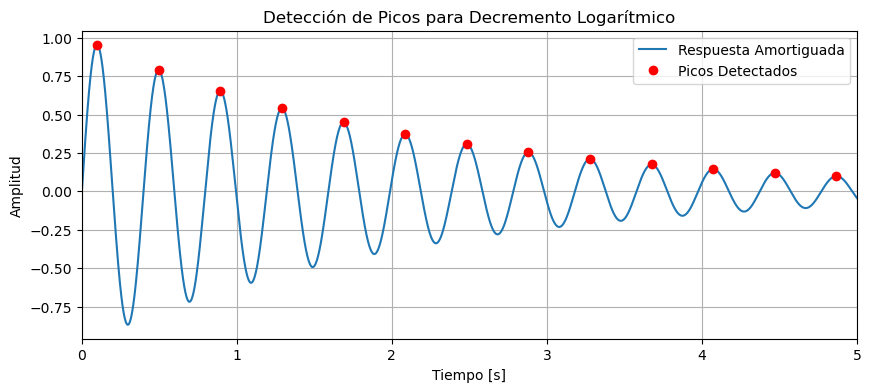

In [11]:
# 6.1 Generación de Respuesta Dinámica Amortiguada Libre
wd = wn * np.sqrt(1 - zeta_real**2)
x_damped = np.exp(-zeta_real*wn*t) * np.sin(wd*t)

# 6.2 Detección Computacional de Peaks
peaks, _ = find_peaks(x_damped, distance=100)

# Visualización de picos detectados
plt.figure(figsize=(10, 4))
plt.plot(t, x_damped, label="Respuesta Amortiguada")
plt.plot(t[peaks], x_damped[peaks], "ro", label="Picos Detectados")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Detección de Picos para Decremento Logarítmico")
plt.xlim(0, 5)
plt.grid(True)
plt.legend()
plt.show()

In [12]:
# 6.3 Cálculo del Decremento Logarítmico y Parámetros Estructurados
x1 = x_damped[peaks[0]]
xN = x_damped[peaks[5]]
N = 5

delta = (1/N) * np.log(x1/xN)
zeta_estimado = delta / np.sqrt(4*np.pi**2 + delta**2)
c_estimado = 2 * zeta_estimado * np.sqrt(k*m)

print(f"--- COMPARATIVA DE RESULTADOS ---")
print(f"Decremento Logarítmico (Delta): {delta:.4f}")
print(f"Razón Amortiguamiento Real:    {zeta_real:.4f}")
print(f"Razón Amortiguamiento Estimada:{zeta_estimado:.4f}")
print(f"Coeficiente de Amortiguamiento c Estimado: {c_estimado:.2f} Ns/m")

--- COMPARATIVA DE RESULTADOS ---
Decremento Logarítmico (Delta): 0.1886
Razón Amortiguamiento Real:    0.0300
Razón Amortiguamiento Estimada:0.0300
Coeficiente de Amortiguamiento c Estimado: 1.90 Ns/m


## 4.3 Discusión General de Resultados

### 4.3.1 Análisis del Decremento Logarítmico
* **Uso del Logaritmo del Cociente:** Como la envolvente que restringe los máximos decrece de manera exponencial ($e^{-\zeta\omega_n t}$), aplicar el logaritmo actúa como un operador de **linealización**. Transforma la caída exponencial en una pendiente lineal constante y proporcional al amortiguamiento.
* **Relación entre Amortiguamiento y Decremento:** Si el nivel de amortiguamiento de la estructura aumenta, la disipación de energía por ciclo es mayor, las amplitudes sucesivas caen drásticamente y el decremento logarítmico ($\delta$) **aumenta de valor**.
* **Conveniencia de Separar Peaks por Múltiples Ciclos ($N$):** Evaluar picos adyacentes inmediatos ($N=1$) expone al cálculo a errores de precisión numérica por la discretización temporal. Al espaciar la evaluación a lo largo de múltiples ciclos ($N=5$), se promedian las variaciones menores y se incrementa la estabilidad del cálculo.

### 4.3.2 Limitaciones por Ruido y Diferencias Cinemáticas
* **Problemas ante Altos Niveles de Ruido:** El ruido distorsiona la verdadera amplitud máxima de la cresta e introduce falsos máximos locales que confunden al algoritmo `find_peaks`, desplazando la localización del índice temporal exacto del pico.
* **Información Requerida para Obtener el Coeficiente Viscoso ($c$):** El decremento logarítmico provee únicamente la razón adimensional ($\zeta$). Para calcular el coeficiente viscoso absoluto $c$ ($Ns/m$), es estrictamente necesario conocer **la masa ($m$) y la rigidez ($k$) del sistema**, empleando la formulación del amortiguamiento crítico ($c = 2\zeta\sqrt{km}$).
* **Frecuencia Natural No Amortiguada ($f_n$) vs. Amortiguada ($f_d$):** Físicamente, $f_n$ representa un estado ideal de conservación de energía sin disipación. La frecuencia amortiguada ($f_d$) es la frecuencia real a la que oscila el sistema libre en presencia de resistencia viscosa. Debido a la fuerza disipativa que actúa como freno dinámico, **$f_d$ es estrictamente menor que $f_n$**. No obstante, para estructuras convencionales con bajo amortiguamiento ($\zeta < 0.05$), la diferencia es numéricamente despreciable.

### 4.3.4 Implementación Práctica con Sensores de Aceleración
En la práctica de la ingeniería estructural, es complejo medir desplazamientos directos ($x(t)$) en puentes o edificios en condiciones de campo sin un punto fijo de referencia. Por este motivo, se utilizan comúnmente **acelerómetros**. 

El método del decremento logarítmico es **perfectamente aplicable a señales directas de aceleración cruda** sin requerir integraciones numéricas. Esto se sostiene debido a que, al derivar temporalmente la ecuación de desplazamiento de un sistema subamortiguado, la aceleración resultante ($\ddot{x}(t)$) mantiene exactamente la misma tasa de decaimiento exponencial ($e^{-\zeta\omega_n t}$) y la misma periodicidad amortiguada ($\omega_d$).

# 5.  Función de transferencia
## Interpretación Física de la Función de Transferencia (FRF)

Hasta ahora se ha estudiado la respuesta libre amortiguada de un sistema. Sin embargo, en aplicaciones reales las estructuras suelen estar sometidas a fuerzas externas continuas, como vibraciones de maquinaria, viento, tránsito o excitaciones sísmicas.

Para un sistema masa–resorte–amortiguador sometido a una fuerza externa:

$$
m\ddot{x}(t)+c\dot{x}(t)+kx(t)=f(t)
$$

es posible definir una relación entre la entrada (fuerza aplicada) y la salida (respuesta del sistema) en el dominio de la frecuencia.

La Función de Respuesta en Frecuencia (FRF) o receptancia se define como:

$$
H(\omega)=\frac{X(\omega)}{F(\omega)}
=
\frac{1}{k-m\omega^2+jc\omega}
$$

Esta función describe cuánto responde una estructura ante una excitación aplicada a cada frecuencia.

Su comportamiento está gobernado por tres regiones principales:

- **Zona controlada por rigidez** ($\omega \ll \omega_n$)
- **Zona resonante** ($\omega \approx \omega_n$)
- **Zona controlada por masa** ($\omega \gg \omega_n$)

El máximo de la FRF identifica la resonancia del sistema, mientras que la posición y forma de la curva permiten estimar propiedades dinámicas como frecuencia natural, masa, rigidez y amortiguamiento.

En términos físicos, la FRF transforma el problema:

$$
f(t)\rightarrow x(t)
$$

desde una descripción temporal hacia una descripción frecuencial, permitiendo analizar cómo reaccionará una estructura frente a excitaciones externas de distinta frecuencia.

In [21]:
# Parámetros físicos
mass = 10.0          # kg
stiffness = 4000.0   # N/m
zeta = 0.04          # razón de amortiguamiento

# Frecuencia natural
omega_n = np.sqrt(stiffness / mass)
fn_hz = omega_n / (2 * np.pi)

# Coeficiente de amortiguamiento viscoso
c = 2 * zeta * mass * omega_n

print(f"Masa m = {mass:.2f} kg")
print(f"Rigidez k = {stiffness:.2f} N/m")
print(f"Razón de amortiguamiento zeta = {zeta:.4f}")
print(f"Coeficiente de amortiguamiento c = {c:.3f} N s/m")
print(f"Frecuencia natural fn = {fn_hz:.3f} Hz")

Masa m = 10.00 kg
Rigidez k = 4000.00 N/m
Razón de amortiguamiento zeta = 0.0400
Coeficiente de amortiguamiento c = 16.000 N s/m
Frecuencia natural fn = 3.183 Hz


In [22]:
# Vector de frecuencias
frequencies_hz = np.linspace(0.01, 30, 3000)
omega = 2 * np.pi * frequencies_hz

# Función de transferencia: desplazamiento / fuerza
H = 1 / (stiffness - mass * omega**2 + 1j * c * omega)

H_magnitude = np.abs(H)
H_phase = np.angle(H, deg=True)

# Frecuencia donde la magnitud es máxima
resonance_frequency_hz = frequencies_hz[np.argmax(H_magnitude)]

print(f"Frecuencia natural teórica fn = {fn_hz:.3f} Hz")
print(f"Frecuencia de máximo |H| = {resonance_frequency_hz:.3f} Hz")

Frecuencia natural teórica fn = 3.183 Hz
Frecuencia de máximo |H| = 3.180 Hz


In [34]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

def graficar_admitancia_interactivo(mass, stiffness, damping_ratio):
    """
    Gráfico interactivo de la admitancia H(w) = 1/(k - m w^2 + j c w).
    Muestra magnitud (con zonas de control) y fase.
    """
    # Vector de frecuencias (0.01 a 30 Hz)
    freqs = np.linspace(0.01, 30, 3000)
    omega = 2 * np.pi * freqs

    # Parámetros derivados
    omega_n = np.sqrt(stiffness / mass)
    fn = omega_n / (2 * np.pi)
    c = 2 * damping_ratio * mass * omega_n

    # Función de transferencia
    H = 1 / (stiffness - mass * omega**2 + 1j * c * omega)
    H_mag = np.abs(H)
    H_fase = np.angle(H, deg=True)

    # Frecuencia del pico de magnitud
    idx_pico = np.argmax(H_mag)
    f_pico = freqs[idx_pico]

    # Límites de las regiones de control
    baja_lim = 0.5 * fn
    alta_lim = 2.0 * fn

    # Figura con dos subgráficos
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # ---- Magnitud ----
    ax1.semilogy(freqs, H_mag, color='blue', linewidth=2, label='|H(ω)|')
    # Regiones coloreadas
    ax1.axvspan(freqs[0], baja_lim, alpha=0.12, color='green', label='Rigidez')
    ax1.axvspan(baja_lim, alta_lim, alpha=0.12, color='orange', label='Amortiguamiento')
    ax1.axvspan(alta_lim, freqs[-1], alpha=0.12, color='red', label='Masa')
    # Líneas de frecuencia
    ax1.axvline(fn, color='black', linestyle='--', linewidth=2,
                label=f'$f_n$ = {fn:.2f} Hz')
    ax1.axvline(f_pico, color='gray', linestyle=':', linewidth=1.5,
                label=f'Pico = {f_pico:.2f} Hz')

    ax1.set_title(f'Magnitud de la admitancia |H(ω)|\nζ = {damping_ratio:.3f}')
    ax1.set_xlabel('Frecuencia [Hz]')
    ax1.set_ylabel('|H(ω)| [m/N]')
    ax1.set_xlim(0, 30)
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper right')

    # ---- Fase ----
    ax2.plot(freqs, H_fase, color='crimson', linewidth=2, label='∠H(ω)')
    ax2.axvline(fn, color='black', linestyle='--', linewidth=2,
                label=f'$f_n$ = {fn:.2f} Hz')
    ax2.set_title(f'Fase de la admitancia\nζ = {damping_ratio:.3f}')
    ax2.set_xlabel('Frecuencia [Hz]')
    ax2.set_ylabel('Fase [grados]')
    ax2.set_ylim(-190, 10)
    ax2.set_xlim(0, 30)
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='lower right')

    plt.tight_layout()
    plt.show()
    plt.close(fig)

# Interfaz interactiva
interact(graficar_admitancia_interactivo,
         mass=FloatSlider(value=10.0, min=0.5, max=20.0, step=0.5,
                          description='Masa [kg]'),
         stiffness=FloatSlider(value=4000.0, min=500.0, max=10000.0, step=100.0,
                               description='Rigidez [N/m]'),
         damping_ratio=FloatSlider(value=0.04, min=0.001, max=0.5, step=0.005,
                                   description='Amortiguamiento ζ'));

interactive(children=(FloatSlider(value=10.0, description='Masa [kg]', max=20.0, min=0.5, step=0.5), FloatSlid…

## Preguntas de Discusión e Interpretación Física

### ¿Por qué en baja frecuencia $H(\omega)=1/k$?

La función de transferencia para la admitancia dinámica está dada por:

$$
H(\omega)=\frac{1}{k-m\omega^2+jc\omega}
$$

Cuando la frecuencia angular tiende a cero:

$$
\omega\rightarrow0
$$

los términos dinámicos disminuyen:

$$
m\omega^2\rightarrow0
$$

$$
c\omega\rightarrow0
$$

por lo que la expresión se aproxima a:

$$
H(\omega)\approx\frac{1}{k}
$$

Esto significa que en bajas frecuencias el sistema se comporta prácticamente como un resorte estático, donde la relación entre fuerza y desplazamiento está gobernada por:

$$
F=kx
$$

o equivalentemente:

$$
x=\frac{F}{k}
$$

Dado que:

$$
H=\frac{x}{F}
$$

se obtiene:

$$
H=\frac1k
$$

**Interpretación física:**
En baja frecuencia domina el efecto de la rigidez y los efectos de masa y amortiguamiento son despreciables.

---

### ¿Qué ocurre con el peak de resonancia si aumenta el amortiguamiento?

La razón de amortiguamiento $\zeta$ controla la cantidad de energía que el sistema disipa durante el movimiento.

Al aumentar el amortiguamiento:

* La altura del pico disminuye.
* La curva se vuelve más ancha.
* La amplificación máxima disminuye.

Cerca de resonancia:

$$
|H|_{max}\propto\frac{1}{2\zeta}
$$

Por lo tanto:

$$
\zeta\uparrow
\quad\Rightarrow\quad
|H|_{max}\downarrow
$$

**Interpretación física:**
El sistema absorbe menos energía vibratoria y responde con menores amplitudes.

---

### ¿Qué ocurre con la frecuencia natural si aumenta la rigidez?

La frecuencia natural del sistema está definida como:

$$
\omega_n=\sqrt{\frac{k}{m}}
$$

Si aumenta la rigidez:

$$
k\uparrow
$$

entonces:

$$
\omega_n\uparrow
$$

**Interpretación física:**
Una estructura más rígida recupera más rápidamente su posición de equilibrio y oscila a mayor frecuencia.

En una FRF esto se observa como un desplazamiento del pico hacia frecuencias más altas.

---

### ¿Qué ocurre con la frecuencia natural si aumenta la masa?

Usando la misma relación:

$$
\omega_n=\sqrt{\frac{k}{m}}
$$

si aumenta la masa:

$$
m\uparrow
$$

entonces:

$$
\omega_n\downarrow
$$

**Interpretación física:**
Una mayor masa incrementa la inercia del sistema y disminuye la velocidad con que puede oscilar.

En una FRF esto se observa como un desplazamiento del pico hacia frecuencias menores.

---

### ¿Por qué en alta frecuencia domina el término $m\omega^2$?

Partiendo nuevamente desde:

$$
H(\omega)=\frac1{k-m\omega^2+jc\omega}
$$

para valores elevados de frecuencia:

$$
\omega\rightarrow\infty
$$

los términos crecen con distinto orden:

$$
k\sim constante
$$

$$
c\omega\sim\omega
$$

$$
m\omega^2\sim\omega^2
$$

Por lo tanto:

$$
H(\omega)\approx\frac1{-m\omega^2}
$$

**Interpretación física:**
En altas frecuencias domina la inercia y el sistema se vuelve resistente a cambios rápidos de aceleración.

---

### Diferencia entre receptancia, movilidad y acelerancia

Todas corresponden a funciones de respuesta en frecuencia (FRF), pero difieren en la variable de salida utilizada.

#### Receptancia

Relaciona desplazamiento con fuerza:

$$
H_x=\frac{X}{F}
$$

Unidad:

$$
[m/N]
$$

Interpretación:

> ¿Cuánto se desplaza la estructura por unidad de fuerza?

---

#### Movilidad

Relaciona velocidad con fuerza:

$$
H_v=\frac{V}{F}
$$

como:

$$
V=j\omega X
$$

entonces:

$$
H_v=j\omega H_x
$$

Unidad:

$$
[m/s]/N
$$

Interpretación:

> ¿Qué velocidad alcanza la estructura?

---

#### Acelerancia

Relaciona aceleración con fuerza:

$$
H_a=\frac{A}{F}
$$

como:

$$
A=-\omega^2X
$$

entonces:

$$
H_a=-\omega^2H_x
$$

Unidad:

$$
[m/s^2]/N
$$

Interpretación:

> ¿Qué aceleración produce una fuerza aplicada?

---

### ¿Por qué la acelerancia es tan utilizada en análisis modal experimental?

La acelerancia es ampliamente utilizada porque la aceleración puede medirse directamente mediante acelerómetros.

Ventajas:

* Alta sensibilidad.
* Buena respuesta frecuencial.
* Menor susceptibilidad al ruido.
* Fácil integración experimental.

Además, se relaciona directamente con la dinámica mediante:

$$
F=ma
$$

Por ello muchas FRF experimentales se expresan como:

$$
[m/s^2]/N
$$

---

### ¿Cómo medir experimentalmente una FRF usando un martillo modal?

La medición experimental de una FRF consiste en registrar simultáneamente:

* Fuerza aplicada.
* Respuesta estructural.

Procedimiento:

1. Aplicar un impacto mediante un martillo instrumentado.

$$
F(t)
$$

2. Medir la respuesta utilizando un acelerómetro.

$$
a(t)
$$

3. Transformar ambas señales mediante FFT:

$$
F(\omega)
\qquad
A(\omega)
$$

4. Calcular la función de transferencia:

$$
H(\omega)=\frac{A(\omega)}{F(\omega)}
$$

Los máximos de la FRF permiten identificar:

* Frecuencias naturales.
* Amortiguamiento.
* Modos de vibración.

**Interpretación física:**
La FRF cuantifica cuánto responde la estructura frente a excitaciones externas en función de la frecuencia aplicada.


## 9. Conclusiones

1. La Densidad Espectral de Potencia (PSD) es una técnica eficiente para la identificación de frecuencias naturales dominantes, permitiendo aislar las componentes energéticas principales de una estructura.
2. El algoritmo de Welch ofrece ventajas sustanciales sobre la FFT directa en entornos ruidosos, puesto que reduce la varianza espectral promediando segmentos temporales superpuestos.
3. El incremento del tiempo de registro dinámico ($T$) impacta positivamente la resolución en frecuencia ($\Delta f$), posibilitando la correcta discriminación de picos espectrales densos.
4. El método del decremento logarítmico linealiza con precisión el decaimiento de energía y estima de forma exacta la razón de amortiguamiento estructural, demostrando mayor robustez cuando se evalúan picos separados por múltiples ciclos.
5. Los efectos ambientales y el ruido instrumental imponen restricciones a los algoritmos automáticos de detección de peaks temporales, requiriendo etapas previas de filtrado digital para resguardar la validez de los parámetros identificados.
6. La equivalencia en las tasas de decaimiento entre las variables cinemáticas valida el uso directo de acelerómetros en pruebas de vibración libre, consolidando a estas herramientas computacionales como soluciones viables para el monitoreo de salud estructural y evaluación de daño.

---

## 10. Referencias

[1] Inman, D. J., *Engineering Vibrations*, Prentice Hall.  
[2] Chopra, A. K., *Dynamics of Structures*, Pearson.  
[3] SciPy Signal Processing Documentation (`scipy.signal.welch`, `scipy.signal.find_peaks`).  
[4] NumPy Mathematical Functions Documentation.